TAME perturbations intensity on original data, to test if there is a difference with Wiener Filtering.

En of er andere features bij OpenSMILE uitkomen

In [ ]:
# Standard libraries
from pathlib import Path
import os
from matplotlib.colors import Normalize
from pathlib import Path
import subprocess
import pandas as pd
import tempfile
from sklearn.preprocessing import StandardScaler
from scipy.io import wavfile
from scipy.signal import wiener
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load data
DATA_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME")
WIENER_INPUT_DIR = DATA_PATH / "selected_original_audio_pain"
INTENSITY_OUTPUT_DIR = DATA_PATH / "original_intensity_perturbations_pain"

INTENSITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [30]:
#collect wav files
audio_files = []

for root, dirs, files in os.walk(WIENER_INPUT_DIR):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print(f"Number of Wiener-filtered audio files: {len(audio_files)}")

Number of Wiener-filtered audio files: 1005


In [31]:
def load_wav_file(file_path):
    """
    Load a WAV file and return sample rate and signal.
    """
    sample_rate, signal = wavfile.read(file_path)
    return sample_rate, signal


def save_wav_file(file_path, sample_rate, signal):
    """
    Save a WAV file as int16.
    """
    signal = np.clip(signal, -32768, 32767) #so the signal remains in the 16 bit format 
    signal = signal.astype(np.int16)
    wavfile.write(file_path, sample_rate, signal)

def change_audio_intensity(signal, gain_db):
    """
    Change audio intensity by applying gain in dB.

    Parameters
    signal : np.ndarray
        Input audio signal
    gain_db : float
        Gain in decibels

    Returns
    adjusted_signal : np.ndarray
        Intensity-adjusted audio signal
    """
    signal = signal.astype(np.float32)

    # Convert dB to linear amplitude factor
    gain_factor = 10 ** (gain_db / 20.0)

    adjusted_signal = signal * gain_factor
    return adjusted_signal


def make_perturbation_output_path(input_path, input_root, output_root, perturbation_name):
    """
    Save perturbed audio in:
    output_root / perturbation_name / PID / original_filename.wav
    """
    relative_path = os.path.relpath(input_path, input_root)
    output_path = os.path.join(output_root, perturbation_name, relative_path)

    output_dir = os.path.dirname(output_path)
    os.makedirs(output_dir, exist_ok=True)

    return output_path

In [32]:
# dB steps
step_dB = 3

perturbations = {
    "-6dB": -2 * step_dB,   # -6 dB
    "-3dB":  -1 * step_dB,   # -3 dB
    "+3dB":    1 * step_dB,   # +3 dB
    "+6dB":   2 * step_dB    # +6 dB
}

In [33]:
#save the different levels of dB in a new map 
processed_rows = []

for input_path in audio_files:
    try:
        sample_rate, signal = load_wav_file(input_path)

        for perturbation_name, gain_db in perturbations.items():
            adjusted_signal = change_audio_intensity(signal, gain_db)

            output_path = make_perturbation_output_path(
                input_path=input_path,
                input_root=WIENER_INPUT_DIR,
                output_root=INTENSITY_OUTPUT_DIR,
                perturbation_name=perturbation_name
            )

            save_wav_file(output_path, sample_rate, adjusted_signal)

            participant_id = os.path.basename(os.path.dirname(input_path))
            filename = os.path.basename(input_path)

            processed_rows.append({
                "participant_id": participant_id,
                "filename": filename,
                "original_wiener_file_path": input_path,
                "perturbation": perturbation_name,
                "gain_db": gain_db,
                "perturbed_file_path": output_path
            })

    except Exception as e:
        print(f"Error processing {input_path}: {e}")

print(os.path.exists(input_path))

True


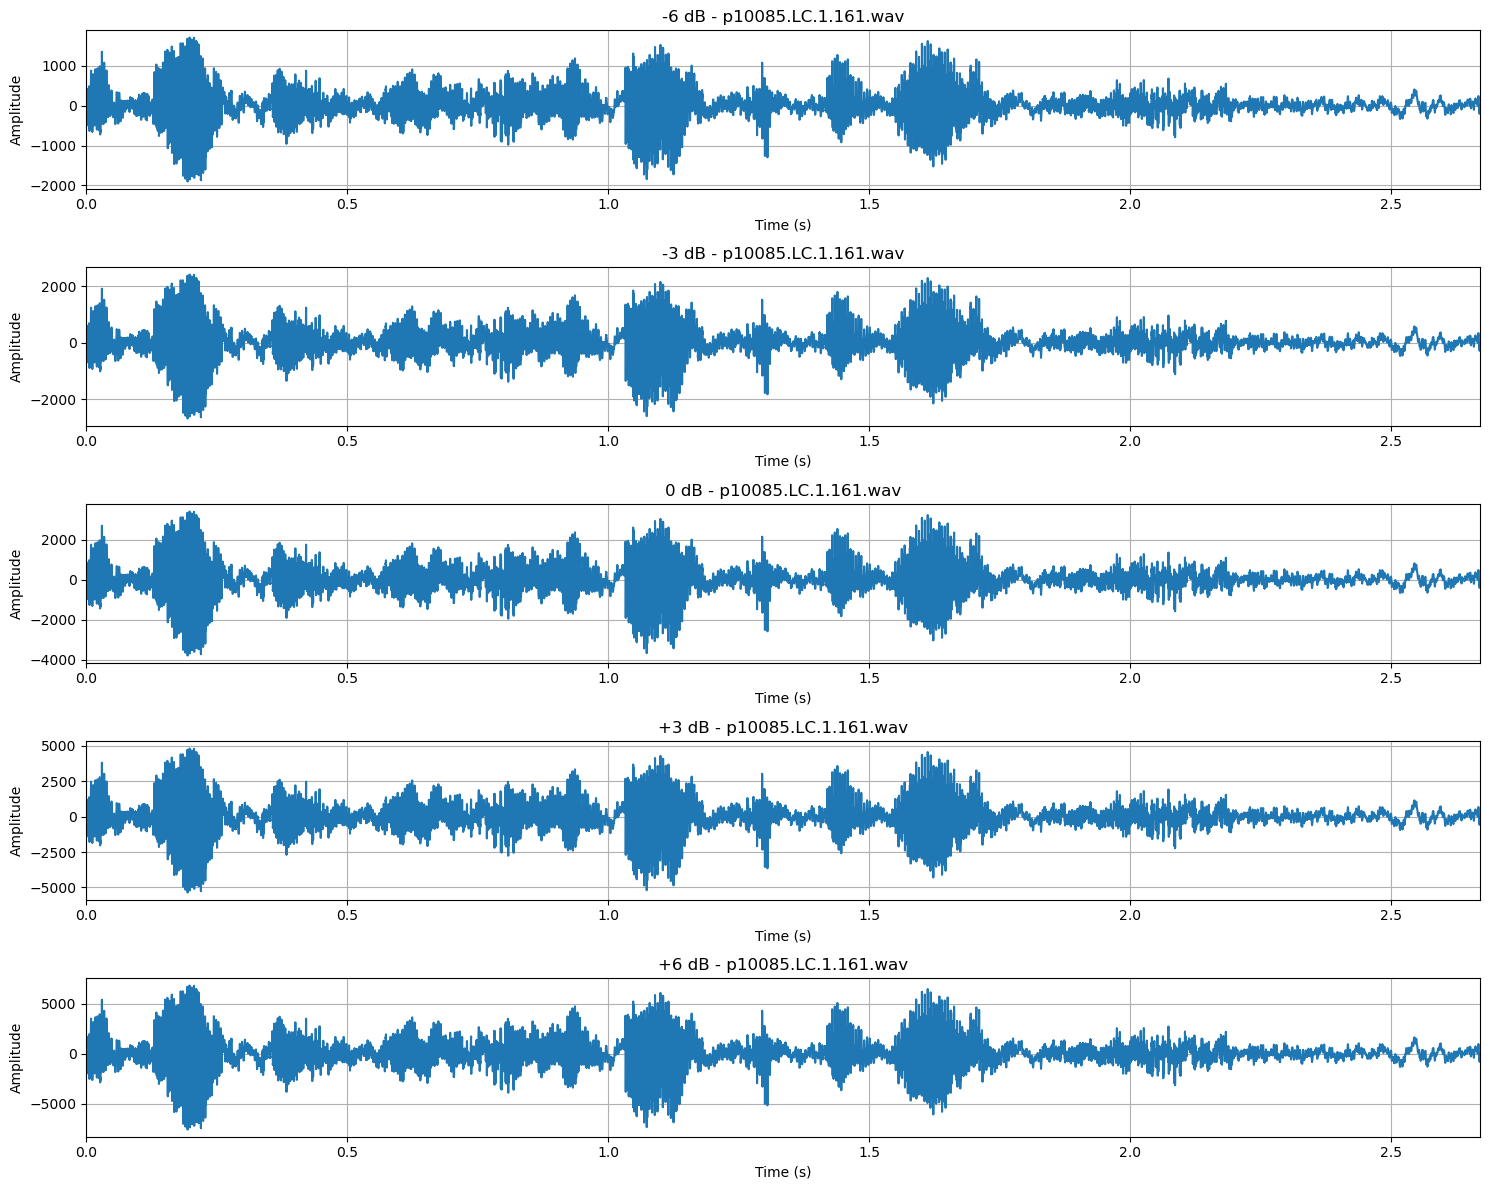

In [34]:
# which participant plot
participant_id = "p10085"
filename = "p10085.LC.1.161.wav"

original_file = os.path.join(WIENER_INPUT_DIR, participant_id, filename)

perturbed_files = {
    "-6 dB": os.path.join(INTENSITY_OUTPUT_DIR, "-6dB", participant_id, filename),
    "-3 dB": os.path.join(INTENSITY_OUTPUT_DIR, "-3dB", participant_id, filename),
    "0 dB": original_file,
    "+3 dB": os.path.join(INTENSITY_OUTPUT_DIR, "+3dB", participant_id, filename),
    "+6 dB": os.path.join(INTENSITY_OUTPUT_DIR, "+6dB", participant_id, filename),
}

# Plot
plt.figure(figsize=(15, 12))

for i, (label, file_path) in enumerate(perturbed_files.items(), 1):
    sample_rate, signal = load_wav_file(file_path)
    signal = signal.astype(np.float32)

    time = np.arange(len(signal)) / sample_rate

    plt.subplot(5, 1, i)
    plt.plot(time, signal)
    plt.title(f"{label} - {filename}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.xlim(0, min(3, time[-1]))  # eerste 3 seconden
    plt.grid(True)

plt.tight_layout()
plt.show()

OpenSMILE toepassen hierop, 3dB

In [35]:
# paths
BASE_DIR = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

OPENSMILE_EXE = BASE_DIR / "tools" / "openSMILE" / "bin" / "SMILExtract.exe"
CONFIG_FILE = BASE_DIR / "tools" / "openSMILE" / "config" / "egemaps" / "v02" / "eGeMAPSv02.conf"

AUDIO_ROOT = BASE_DIR / "TAME" / "original_intensity_perturbations_pain" / "+3dB"

OUTPUT_FEATURES_CSV = BASE_DIR / "original_opensmile_intensity_3dB_features_pain.csv"
OUTPUT_FAILED_CSV = BASE_DIR / "original_opensmile_intensity_3dB_failed_files.csv"

# check
print("SMILExtract exists:", OPENSMILE_EXE.exists())
print("Config exists:", CONFIG_FILE.exists())
print("Audio root exists:", AUDIO_ROOT.exists())

if not OPENSMILE_EXE.exists():
    raise FileNotFoundError(f"SMILExtract.exe not found:\n{OPENSMILE_EXE}")

if not CONFIG_FILE.exists():
    raise FileNotFoundError(f"Config file not found:\n{CONFIG_FILE}")

if not AUDIO_ROOT.exists():
    raise FileNotFoundError(f"Audio root not found:\n{AUDIO_ROOT}")

#WAV files
wav_files = sorted(AUDIO_ROOT.rglob("*.wav"))
print(f"Number of wav. files found: {len(wav_files)}")

if len(wav_files) == 0:
    raise ValueError("no .wav files found.")

# Run OpenSMILE
all_rows = []
failed_files = []

for i, wav_file in enumerate(wav_files, start=1):
    print(f"[{i}/{len(wav_files)}] Processing: {wav_file.name}")

    participant_id = wav_file.parent.name
    filename = wav_file.name

    with tempfile.NamedTemporaryFile(suffix=".csv", delete=False) as tmp:
        temp_output_csv = Path(tmp.name)

    try:
        if temp_output_csv.exists():
            temp_output_csv.unlink(missing_ok=True)

        cmd = [
            str(OPENSMILE_EXE),
            "-C", str(CONFIG_FILE),
            "-I", str(wav_file),
            "-csvoutput", str(temp_output_csv),
        ]

        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.returncode != 0:
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": "openSMILE return code != 0",
                "stderr": result.stderr
            })
            continue

        if not temp_output_csv.exists():
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": "no output made",
                "stderr": result.stderr
            })
            continue

        try:
            feature_df = pd.read_csv(temp_output_csv, sep=";", engine="python")
        except Exception as e:
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": f"error in csv: {e}",
                "stderr": result.stderr
            })
            continue

        if feature_df.empty:
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": "Output csv is leeg",
                "stderr": result.stderr
            })
            continue

        #adding information 
        row = feature_df.iloc[0].to_dict()
        row["name"] = filename
        row["participant_id"] = participant_id
        row["filename"] = filename
        row["file_path"] = str(wav_file)

        all_rows.append(row)

    except Exception as e:
        failed_files.append({
            "participant_id": participant_id,
            "filename": filename,
            "file_path": str(wav_file),
            "reason": f"error {e}",
            "stderr": ""
        })

    finally:
        if temp_output_csv.exists():
            temp_output_csv.unlink(missing_ok=True)


#Save
features_df = pd.DataFrame(all_rows)

# Kolommen netjes ordenen
preferred_front_cols = ["participant_id", "filename", "file_path", "name", "frameTime"]
remaining_cols = [col for col in features_df.columns if col not in preferred_front_cols]
features_df = features_df[[col for col in preferred_front_cols if col in features_df.columns] + remaining_cols]

features_df.to_csv(OUTPUT_FEATURES_CSV, index=False)

print("\nKlaar.")
print("number of errors in features:", len(features_df))
print("numer of errors in the files:", len(failed_files))
print("Features saves in :")
print(OUTPUT_FEATURES_CSV)

if failed_files:
    failed_df = pd.DataFrame(failed_files)
    failed_df.to_csv(OUTPUT_FAILED_CSV, index=False)
    print("\n errors saved:")
    print(OUTPUT_FAILED_CSV)


# Results
print("\nShape features dataframe:", features_df.shape)
display(features_df.head())

SMILExtract exists: True
Config exists: True
Audio root exists: True
Number of wav. files found: 1005
[1/1005] Processing: p10085.LC.1.161.wav
[2/1005] Processing: p10085.LC.12.59.wav
[3/1005] Processing: p10085.LC.14.45.wav
[4/1005] Processing: p10085.LC.18.41.wav
[5/1005] Processing: p10085.LC.2.106.wav
[6/1005] Processing: p10085.LC.23.156.wav
[7/1005] Processing: p10085.LC.24.172.wav
[8/1005] Processing: p10085.LC.26.99999.wav
[9/1005] Processing: p10085.LC.3.60.wav
[10/1005] Processing: p10085.LC.30.132.wav
[11/1005] Processing: p10085.LC.31.99999.wav
[12/1005] Processing: p10085.LC.33.6.wav
[13/1005] Processing: p10085.LC.34.122.wav
[14/1005] Processing: p10085.LC.37.71.wav
[15/1005] Processing: p10085.LC.38.160.wav
[16/1005] Processing: p10085.LC.4.76.wav
[17/1005] Processing: p10085.LC.40.174.wav
[18/1005] Processing: p10085.LC.41.99999.wav
[19/1005] Processing: p10085.LC.5.134.wav
[20/1005] Processing: p10085.LC.6.99999.wav
[21/1005] Processing: p10085.LC.9.55.wav
[22/1005] Pr

,participant_id,filename,file_path,name,frameTime,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,p10085,p10085.LC.1.161.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.1.161.wav,0.0,35.01982,0.058435,32.85135,34.98661,36.56275,...,-0.023911,-0.014601,0.137553,3.759399,3.065134,0.107500,0.047368,0.175556,0.172118,-31.58870
1,p10085,p10085.LC.12.59.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.12.59.wav,0.0,36.45980,0.054268,35.04674,35.46412,38.76046,...,-0.024243,-0.010789,0.133698,4.245283,2.415459,0.140000,0.077974,0.254000,0.238462,-30.72772
2,p10085,p10085.LC.14.45.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.14.45.wav,0.0,34.32709,0.041926,33.18596,33.72220,35.32523,...,-0.027261,-0.012615,0.137877,3.524229,2.252252,0.196000,0.151737,0.226000,0.256094,-31.09913
3,p10085,p10085.LC.18.41.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.18.41.wav,0.0,34.30872,0.110542,33.53382,34.41000,36.70711,...,-0.016414,-0.018602,0.130766,4.017857,3.196347,0.127143,0.137811,0.165714,0.139577,-32.13254
4,p10085,p10085.LC.2.106.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.2.106.wav,0.0,35.14965,0.062775,33.52358,34.20151,37.36132,...,-0.026046,-0.012304,0.118262,2.966102,2.164502,0.180000,0.093595,0.258000,0.288056,-30.76879


OpenSMILE 6dB

In [36]:
# paths
BASE_DIR = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

OPENSMILE_EXE = BASE_DIR / "tools" / "openSMILE" / "bin" / "SMILExtract.exe"
CONFIG_FILE = BASE_DIR / "tools" / "openSMILE" / "config" / "egemaps" / "v02" / "eGeMAPSv02.conf"

AUDIO_ROOT = BASE_DIR / "TAME" / "original_intensity_perturbations_pain" / "+6dB"

OUTPUT_FEATURES_CSV = BASE_DIR / "original_opensmile_intensity_6dB_features_pain.csv"
OUTPUT_FAILED_CSV = BASE_DIR / "original_opensmile_intensity_6dB_failed_files_pain.csv"

# check
print("SMILExtract exists:", OPENSMILE_EXE.exists())
print("Config exists:", CONFIG_FILE.exists())
print("Audio root exists:", AUDIO_ROOT.exists())

if not OPENSMILE_EXE.exists():
    raise FileNotFoundError(f"SMILExtract.exe not found:\n{OPENSMILE_EXE}")

if not CONFIG_FILE.exists():
    raise FileNotFoundError(f"Config file not found:\n{CONFIG_FILE}")

if not AUDIO_ROOT.exists():
    raise FileNotFoundError(f"Audio root not found:\n{AUDIO_ROOT}")

#WAV files
wav_files = sorted(AUDIO_ROOT.rglob("*.wav"))
print(f"Number of wav. files found: {len(wav_files)}")

if len(wav_files) == 0:
    raise ValueError("no .wav files found.")

# Run OpenSMILE
all_rows = []
failed_files = []

for i, wav_file in enumerate(wav_files, start=1):
    print(f"[{i}/{len(wav_files)}] Processing: {wav_file.name}")

    participant_id = wav_file.parent.name
    filename = wav_file.name

    with tempfile.NamedTemporaryFile(suffix=".csv", delete=False) as tmp:
        temp_output_csv = Path(tmp.name)

    try:
        if temp_output_csv.exists():
            temp_output_csv.unlink(missing_ok=True)

        cmd = [
            str(OPENSMILE_EXE),
            "-C", str(CONFIG_FILE),
            "-I", str(wav_file),
            "-csvoutput", str(temp_output_csv),
        ]

        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.returncode != 0:
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": "openSMILE return code != 0",
                "stderr": result.stderr
            })
            continue

        if not temp_output_csv.exists():
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": "no output made",
                "stderr": result.stderr
            })
            continue

        try:
            feature_df = pd.read_csv(temp_output_csv, sep=";", engine="python")
        except Exception as e:
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": f"error in csv: {e}",
                "stderr": result.stderr
            })
            continue

        if feature_df.empty:
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": "Output csv is leeg",
                "stderr": result.stderr
            })
            continue

        #adding information 
        row = feature_df.iloc[0].to_dict()
        row["name"] = filename
        row["participant_id"] = participant_id
        row["filename"] = filename
        row["file_path"] = str(wav_file)

        all_rows.append(row)

    except Exception as e:
        failed_files.append({
            "participant_id": participant_id,
            "filename": filename,
            "file_path": str(wav_file),
            "reason": f"error {e}",
            "stderr": ""
        })

    finally:
        if temp_output_csv.exists():
            temp_output_csv.unlink(missing_ok=True)


#Save
features_df = pd.DataFrame(all_rows)

# Kolommen netjes ordenen
preferred_front_cols = ["participant_id", "filename", "file_path", "name", "frameTime"]
remaining_cols = [col for col in features_df.columns if col not in preferred_front_cols]
features_df = features_df[[col for col in preferred_front_cols if col in features_df.columns] + remaining_cols]

features_df.to_csv(OUTPUT_FEATURES_CSV, index=False)

print("\nKlaar.")
print("number of errors in features:", len(features_df))
print("numer of errors in the files:", len(failed_files))
print("Features saves in :")
print(OUTPUT_FEATURES_CSV)

if failed_files:
    failed_df = pd.DataFrame(failed_files)
    failed_df.to_csv(OUTPUT_FAILED_CSV, index=False)
    print("\n errors saved:")
    print(OUTPUT_FAILED_CSV)


# Results
print("\nShape features dataframe:", features_df.shape)
display(features_df.head())

SMILExtract exists: True
Config exists: True
Audio root exists: True
Number of wav. files found: 1005
[1/1005] Processing: p10085.LC.1.161.wav
[2/1005] Processing: p10085.LC.12.59.wav
[3/1005] Processing: p10085.LC.14.45.wav
[4/1005] Processing: p10085.LC.18.41.wav
[5/1005] Processing: p10085.LC.2.106.wav
[6/1005] Processing: p10085.LC.23.156.wav
[7/1005] Processing: p10085.LC.24.172.wav
[8/1005] Processing: p10085.LC.26.99999.wav
[9/1005] Processing: p10085.LC.3.60.wav
[10/1005] Processing: p10085.LC.30.132.wav
[11/1005] Processing: p10085.LC.31.99999.wav
[12/1005] Processing: p10085.LC.33.6.wav
[13/1005] Processing: p10085.LC.34.122.wav
[14/1005] Processing: p10085.LC.37.71.wav
[15/1005] Processing: p10085.LC.38.160.wav
[16/1005] Processing: p10085.LC.4.76.wav
[17/1005] Processing: p10085.LC.40.174.wav
[18/1005] Processing: p10085.LC.41.99999.wav
[19/1005] Processing: p10085.LC.5.134.wav
[20/1005] Processing: p10085.LC.6.99999.wav
[21/1005] Processing: p10085.LC.9.55.wav
[22/1005] Pr

,participant_id,filename,file_path,name,frameTime,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,p10085,p10085.LC.1.161.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.1.161.wav,0.0,35.01984,0.058435,32.85135,34.98690,36.56286,...,-0.026313,-0.016247,0.194337,3.759399,3.065134,0.107500,0.047368,0.175556,0.172118,-28.58768
1,p10085,p10085.LC.12.59.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.12.59.wav,0.0,36.45980,0.054268,35.04674,35.46410,38.76045,...,-0.026646,-0.012436,0.188892,4.245283,2.415459,0.140000,0.077974,0.254000,0.238462,-27.72683
2,p10085,p10085.LC.14.45.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.14.45.wav,0.0,34.32713,0.041927,33.18588,33.72220,35.32593,...,-0.029667,-0.014263,0.194797,3.524229,2.252252,0.196000,0.151737,0.226000,0.256094,-28.09820
3,p10085,p10085.LC.18.41.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.18.41.wav,0.0,34.30873,0.110540,33.53381,34.41000,36.70712,...,-0.018814,-0.020257,0.184749,4.017857,3.196347,0.127143,0.137811,0.165714,0.139577,-29.13141
4,p10085,p10085.LC.2.106.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.2.106.wav,0.0,35.14960,0.062773,33.52357,34.20152,37.36135,...,-0.028444,-0.013930,0.167088,2.966102,2.164502,0.180000,0.093595,0.258000,0.288056,-27.76791


-3 dB

In [37]:
# paths
BASE_DIR = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

OPENSMILE_EXE = BASE_DIR / "tools" / "openSMILE" / "bin" / "SMILExtract.exe"
CONFIG_FILE = BASE_DIR / "tools" / "openSMILE" / "config" / "egemaps" / "v02" / "eGeMAPSv02.conf"

AUDIO_ROOT = BASE_DIR / "TAME" / "original_intensity_perturbations_pain" / "-3dB"

OUTPUT_FEATURES_CSV = BASE_DIR / "original_opensmile_intensity_-3dB_features_pain.csv"
OUTPUT_FAILED_CSV = BASE_DIR / "original_opensmile_intensity_-3dB_failed_files_pain.csv"

# check
print("SMILExtract exists:", OPENSMILE_EXE.exists())
print("Config exists:", CONFIG_FILE.exists())
print("Audio root exists:", AUDIO_ROOT.exists())

if not OPENSMILE_EXE.exists():
    raise FileNotFoundError(f"SMILExtract.exe not found:\n{OPENSMILE_EXE}")

if not CONFIG_FILE.exists():
    raise FileNotFoundError(f"Config file not found:\n{CONFIG_FILE}")

if not AUDIO_ROOT.exists():
    raise FileNotFoundError(f"Audio root not found:\n{AUDIO_ROOT}")

#WAV files
wav_files = sorted(AUDIO_ROOT.rglob("*.wav"))
print(f"Number of wav. files found: {len(wav_files)}")

if len(wav_files) == 0:
    raise ValueError("no .wav files found.")

# Run OpenSMILE
all_rows = []
failed_files = []

for i, wav_file in enumerate(wav_files, start=1):
    print(f"[{i}/{len(wav_files)}] Processing: {wav_file.name}")

    participant_id = wav_file.parent.name
    filename = wav_file.name

    with tempfile.NamedTemporaryFile(suffix=".csv", delete=False) as tmp:
        temp_output_csv = Path(tmp.name)

    try:
        if temp_output_csv.exists():
            temp_output_csv.unlink(missing_ok=True)

        cmd = [
            str(OPENSMILE_EXE),
            "-C", str(CONFIG_FILE),
            "-I", str(wav_file),
            "-csvoutput", str(temp_output_csv),
        ]

        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.returncode != 0:
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": "openSMILE return code != 0",
                "stderr": result.stderr
            })
            continue

        if not temp_output_csv.exists():
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": "no output made",
                "stderr": result.stderr
            })
            continue

        try:
            feature_df = pd.read_csv(temp_output_csv, sep=";", engine="python")
        except Exception as e:
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": f"error in csv: {e}",
                "stderr": result.stderr
            })
            continue

        if feature_df.empty:
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": "Output csv is leeg",
                "stderr": result.stderr
            })
            continue

        #adding information 
        row = feature_df.iloc[0].to_dict()
        row["name"] = filename
        row["participant_id"] = participant_id
        row["filename"] = filename
        row["file_path"] = str(wav_file)

        all_rows.append(row)

    except Exception as e:
        failed_files.append({
            "participant_id": participant_id,
            "filename": filename,
            "file_path": str(wav_file),
            "reason": f"error {e}",
            "stderr": ""
        })

    finally:
        if temp_output_csv.exists():
            temp_output_csv.unlink(missing_ok=True)


#Save
features_df = pd.DataFrame(all_rows)

# Kolommen netjes ordenen
preferred_front_cols = ["participant_id", "filename", "file_path", "name", "frameTime"]
remaining_cols = [col for col in features_df.columns if col not in preferred_front_cols]
features_df = features_df[[col for col in preferred_front_cols if col in features_df.columns] + remaining_cols]

features_df.to_csv(OUTPUT_FEATURES_CSV, index=False)

print("\nKlaar.")
print("number of errors in features:", len(features_df))
print("numer of errors in the files:", len(failed_files))
print("Features saves in :")
print(OUTPUT_FEATURES_CSV)

if failed_files:
    failed_df = pd.DataFrame(failed_files)
    failed_df.to_csv(OUTPUT_FAILED_CSV, index=False)
    print("\n errors saved:")
    print(OUTPUT_FAILED_CSV)


# Results
print("\nShape features dataframe:", features_df.shape)
display(features_df.head())

SMILExtract exists: True
Config exists: True
Audio root exists: True
Number of wav. files found: 1005
[1/1005] Processing: p10085.LC.1.161.wav
[2/1005] Processing: p10085.LC.12.59.wav
[3/1005] Processing: p10085.LC.14.45.wav
[4/1005] Processing: p10085.LC.18.41.wav
[5/1005] Processing: p10085.LC.2.106.wav
[6/1005] Processing: p10085.LC.23.156.wav
[7/1005] Processing: p10085.LC.24.172.wav
[8/1005] Processing: p10085.LC.26.99999.wav
[9/1005] Processing: p10085.LC.3.60.wav
[10/1005] Processing: p10085.LC.30.132.wav
[11/1005] Processing: p10085.LC.31.99999.wav
[12/1005] Processing: p10085.LC.33.6.wav
[13/1005] Processing: p10085.LC.34.122.wav
[14/1005] Processing: p10085.LC.37.71.wav
[15/1005] Processing: p10085.LC.38.160.wav
[16/1005] Processing: p10085.LC.4.76.wav
[17/1005] Processing: p10085.LC.40.174.wav
[18/1005] Processing: p10085.LC.41.99999.wav
[19/1005] Processing: p10085.LC.5.134.wav
[20/1005] Processing: p10085.LC.6.99999.wav
[21/1005] Processing: p10085.LC.9.55.wav
[22/1005] Pr

,participant_id,filename,file_path,name,frameTime,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,p10085,p10085.LC.1.161.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.1.161.wav,0.0,35.01982,0.058435,32.85137,34.98691,36.56270,...,-0.019098,-0.011328,0.068892,3.759399,3.065134,0.107500,0.047368,0.175556,0.172118,-37.59200
1,p10085,p10085.LC.12.59.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.12.59.wav,0.0,36.45982,0.054269,35.04666,35.46404,38.76054,...,-0.019442,-0.007535,0.066964,4.245283,2.415459,0.140000,0.077974,0.254000,0.238462,-36.73072
2,p10085,p10085.LC.14.45.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.14.45.wav,0.0,34.32711,0.041927,33.18596,33.72219,35.32539,...,-0.022452,-0.009344,0.069053,3.524229,2.252252,0.196000,0.151737,0.226000,0.256094,-37.10236
3,p10085,p10085.LC.18.41.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.18.41.wav,0.0,34.30878,0.110532,33.53381,34.41002,36.70700,...,-0.011595,-0.015316,0.065491,4.017857,3.196347,0.127143,0.137811,0.165714,0.139577,-38.13634
4,p10085,p10085.LC.2.106.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.2.106.wav,0.0,35.14958,0.062773,33.52359,34.20160,37.36095,...,-0.021253,-0.009010,0.059224,2.966102,2.164502,0.180000,0.093595,0.258000,0.288056,-36.77179


-6dB

In [38]:
# paths
BASE_DIR = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

OPENSMILE_EXE = BASE_DIR / "tools" / "openSMILE" / "bin" / "SMILExtract.exe"
CONFIG_FILE = BASE_DIR / "tools" / "openSMILE" / "config" / "egemaps" / "v02" / "eGeMAPSv02.conf"

AUDIO_ROOT = BASE_DIR / "TAME" / "original_intensity_perturbations_pain" / "-6dB"

OUTPUT_FEATURES_CSV = BASE_DIR / "original_opensmile_intensity_-6dB_features_pain.csv"
OUTPUT_FAILED_CSV = BASE_DIR / "original_opensmile_intensity_-6dB_failed_files_pain.csv"

# check
print("SMILExtract exists:", OPENSMILE_EXE.exists())
print("Config exists:", CONFIG_FILE.exists())
print("Audio root exists:", AUDIO_ROOT.exists())

if not OPENSMILE_EXE.exists():
    raise FileNotFoundError(f"SMILExtract.exe not found:\n{OPENSMILE_EXE}")

if not CONFIG_FILE.exists():
    raise FileNotFoundError(f"Config file not found:\n{CONFIG_FILE}")

if not AUDIO_ROOT.exists():
    raise FileNotFoundError(f"Audio root not found:\n{AUDIO_ROOT}")

#WAV files
wav_files = sorted(AUDIO_ROOT.rglob("*.wav"))
print(f"Number of wav. files found: {len(wav_files)}")

if len(wav_files) == 0:
    raise ValueError("no .wav files found.")

# Run OpenSMILE
all_rows = []
failed_files = []

for i, wav_file in enumerate(wav_files, start=1):
    print(f"[{i}/{len(wav_files)}] Processing: {wav_file.name}")

    participant_id = wav_file.parent.name
    filename = wav_file.name

    with tempfile.NamedTemporaryFile(suffix=".csv", delete=False) as tmp:
        temp_output_csv = Path(tmp.name)

    try:
        if temp_output_csv.exists():
            temp_output_csv.unlink(missing_ok=True)

        cmd = [
            str(OPENSMILE_EXE),
            "-C", str(CONFIG_FILE),
            "-I", str(wav_file),
            "-csvoutput", str(temp_output_csv),
        ]

        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.returncode != 0:
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": "openSMILE return code != 0",
                "stderr": result.stderr
            })
            continue

        if not temp_output_csv.exists():
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": "no output made",
                "stderr": result.stderr
            })
            continue

        try:
            feature_df = pd.read_csv(temp_output_csv, sep=";", engine="python")
        except Exception as e:
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": f"error in csv: {e}",
                "stderr": result.stderr
            })
            continue

        if feature_df.empty:
            failed_files.append({
                "participant_id": participant_id,
                "filename": filename,
                "file_path": str(wav_file),
                "reason": "Output csv is leeg",
                "stderr": result.stderr
            })
            continue

        #adding information 
        row = feature_df.iloc[0].to_dict()
        row["name"] = filename
        row["participant_id"] = participant_id
        row["filename"] = filename
        row["file_path"] = str(wav_file)

        all_rows.append(row)

    except Exception as e:
        failed_files.append({
            "participant_id": participant_id,
            "filename": filename,
            "file_path": str(wav_file),
            "reason": f"error {e}",
            "stderr": ""
        })

    finally:
        if temp_output_csv.exists():
            temp_output_csv.unlink(missing_ok=True)


#Save
features_df = pd.DataFrame(all_rows)

# Kolommen netjes ordenen
preferred_front_cols = ["participant_id", "filename", "file_path", "name", "frameTime"]
remaining_cols = [col for col in features_df.columns if col not in preferred_front_cols]
features_df = features_df[[col for col in preferred_front_cols if col in features_df.columns] + remaining_cols]

features_df.to_csv(OUTPUT_FEATURES_CSV, index=False)

print("\nKlaar.")
print("number of errors in features:", len(features_df))
print("numer of errors in the files:", len(failed_files))
print("Features saves in :")
print(OUTPUT_FEATURES_CSV)

if failed_files:
    failed_df = pd.DataFrame(failed_files)
    failed_df.to_csv(OUTPUT_FAILED_CSV, index=False)
    print("\n errors saved:")
    print(OUTPUT_FAILED_CSV)


# Results
print("\nShape features dataframe:", features_df.shape)
display(features_df.head())

SMILExtract exists: True
Config exists: True
Audio root exists: True
Number of wav. files found: 1005
[1/1005] Processing: p10085.LC.1.161.wav
[2/1005] Processing: p10085.LC.12.59.wav
[3/1005] Processing: p10085.LC.14.45.wav
[4/1005] Processing: p10085.LC.18.41.wav
[5/1005] Processing: p10085.LC.2.106.wav
[6/1005] Processing: p10085.LC.23.156.wav
[7/1005] Processing: p10085.LC.24.172.wav
[8/1005] Processing: p10085.LC.26.99999.wav
[9/1005] Processing: p10085.LC.3.60.wav
[10/1005] Processing: p10085.LC.30.132.wav
[11/1005] Processing: p10085.LC.31.99999.wav
[12/1005] Processing: p10085.LC.33.6.wav
[13/1005] Processing: p10085.LC.34.122.wav
[14/1005] Processing: p10085.LC.37.71.wav
[15/1005] Processing: p10085.LC.38.160.wav
[16/1005] Processing: p10085.LC.4.76.wav
[17/1005] Processing: p10085.LC.40.174.wav
[18/1005] Processing: p10085.LC.41.99999.wav
[19/1005] Processing: p10085.LC.5.134.wav
[20/1005] Processing: p10085.LC.6.99999.wav
[21/1005] Processing: p10085.LC.9.55.wav
[22/1005] Pr

,participant_id,filename,file_path,name,frameTime,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,p10085,p10085.LC.1.161.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.1.161.wav,0.0,35.01979,0.058435,32.85075,34.98679,36.56271,...,-0.016694,-0.009652,0.048743,3.759399,3.065134,0.107500,0.047368,0.175556,0.172118,-40.59483
1,p10085,p10085.LC.12.59.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.12.59.wav,0.0,36.45984,0.054269,35.04668,35.46415,38.76050,...,-0.017030,-0.005880,0.047378,4.245283,2.415459,0.140000,0.077974,0.254000,0.238462,-39.73326
2,p10085,p10085.LC.14.45.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.14.45.wav,0.0,34.32711,0.041927,33.18595,33.72218,35.32600,...,-0.020040,-0.007690,0.048857,3.524229,2.252252,0.196000,0.151737,0.226000,0.256094,-40.10503
3,p10085,p10085.LC.18.41.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.18.41.wav,0.0,34.30875,0.110542,33.53381,34.41003,36.70716,...,-0.009189,-0.013676,0.046335,4.017857,3.196347,0.127143,0.137811,0.165714,0.139577,-41.13942
4,p10085,p10085.LC.2.106.wav,C:\Users\marti\Documents\Technical Medicine Ma...,p10085.LC.2.106.wav,0.0,35.14966,0.062776,33.52360,34.20155,37.36126,...,-0.018824,-0.007371,0.041902,2.966102,2.164502,0.180000,0.093595,0.258000,0.288056,-39.77417


Robustness evaluation without standardisation

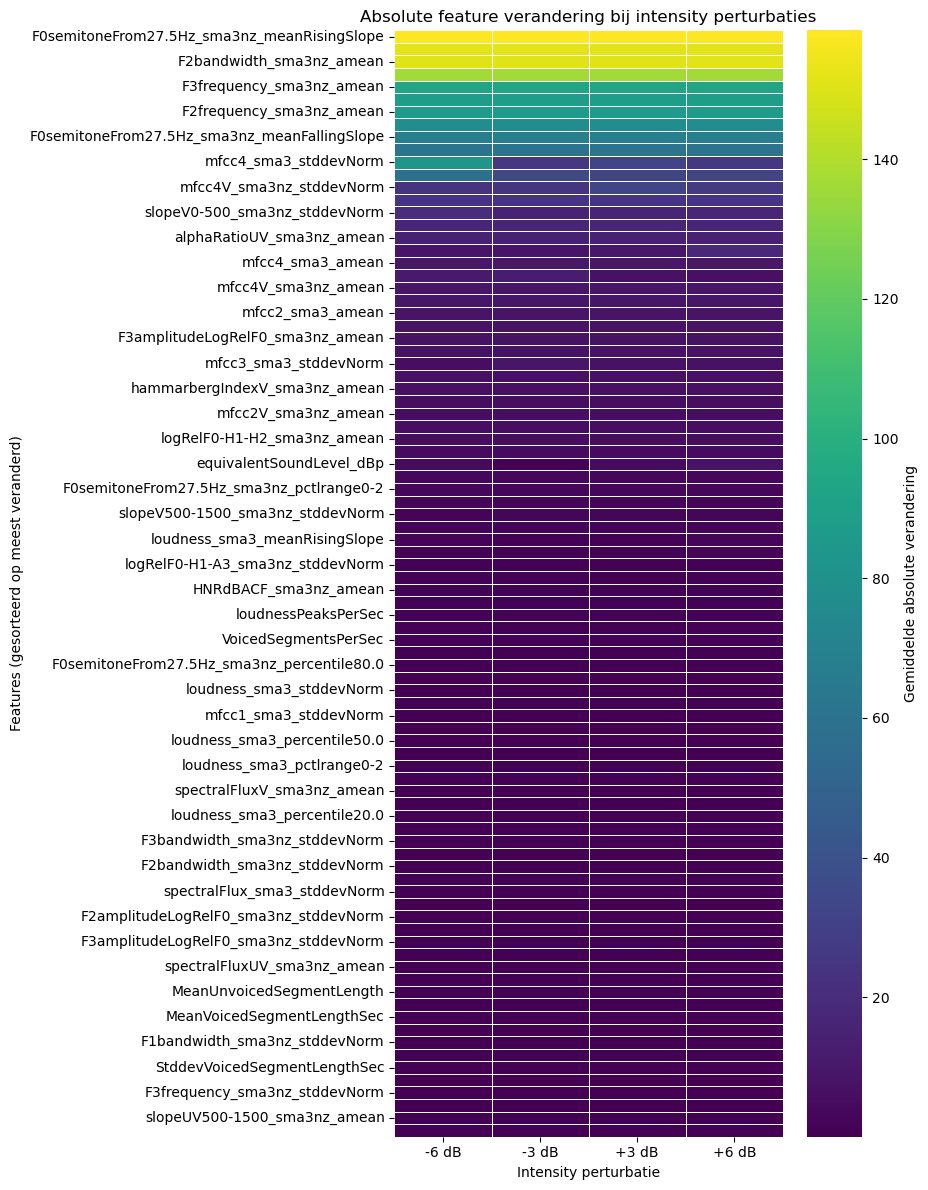

In [39]:
# path
BASE_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht"

files = {
    "original": os.path.join(BASE_PATH, "opensmile_wiener_features.csv"),
    "-6 dB": os.path.join(BASE_PATH, "original_opensmile_intensity_-6dB_features_pain.csv"),
    "-3 dB": os.path.join(BASE_PATH, "original_opensmile_intensity_-3dB_features_pain.csv"),
    "+3 dB": os.path.join(BASE_PATH, "original_opensmile_intensity_3dB_features_pain.csv"),
    "+6 dB": os.path.join(BASE_PATH, "original_opensmile_intensity_6dB_features_pain.csv"),
}


# data
dfs = {k: pd.read_csv(v) for k, v in files.items()}
for k in dfs:
    dfs[k] = dfs[k].sort_values(by=["participant_id", "filename"]).reset_index(drop=True)

reference_ids = dfs["original"][["participant_id", "filename"]]

for key in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    if not reference_ids.equals(dfs[key][["participant_id", "filename"]]):
        raise ValueError(f"Mismatch in {key}")


# features 
exclude_cols = ["participant_id", "filename", "file_path", "name"]
numeric_cols = dfs["original"].select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]



#Absolute difference
abs_diff_means = {}

original_features = dfs["original"][feature_cols]

for condition in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    perturbed_features = dfs[condition][feature_cols]

    abs_diff = np.abs(perturbed_features - original_features)

    abs_diff_means[condition] = abs_diff.mean(axis=0) #mean for the rows (files)



# heatmap 
heatmap_df = pd.DataFrame(abs_diff_means)

heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
heatmap_df = heatmap_df.drop(columns=["mean_change"])

top_n = 88 #for all features 
heatmap_top = heatmap_df.head(top_n)


plt.figure(figsize=(9, 12))

sns.heatmap(
    heatmap_top,
    cmap="viridis",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Gemiddelde absolute verandering"},
    annot=False
)

plt.title("Absolute feature verandering bij intensity perturbaties")
plt.xlabel("Intensity perturbatie")
plt.ylabel("Features (gesorteerd op meest veranderd)")
plt.tight_layout()
plt.show()


Robustness evaluation with standardisation

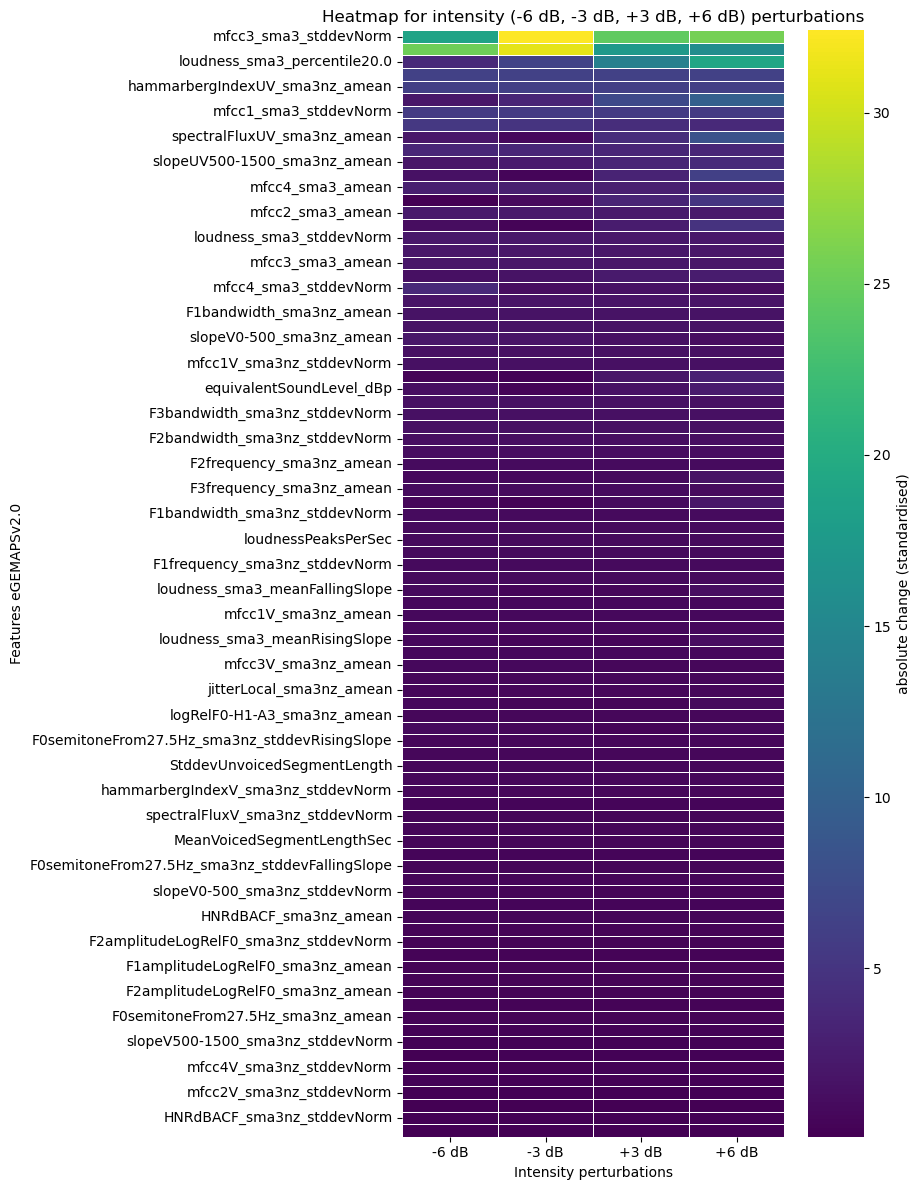

In [ ]:
# path
BASE_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht"

files = {
    "original": os.path.join(BASE_PATH, "opensmile_wiener_features.csv"),
    "-6 dB": os.path.join(BASE_PATH, "original_opensmile_intensity_-6dB_features_pain.csv"),
    "-3 dB": os.path.join(BASE_PATH, "original_opensmile_intensity_-3dB_features_pain.csv"),
    "+3 dB": os.path.join(BASE_PATH, "original_opensmile_intensity_3dB_features_pain.csv"),
    "+6 dB": os.path.join(BASE_PATH, "original_opensmile_intensity_6dB_features_pain.csv"),
}

# data
dfs = {k: pd.read_csv(v) for k, v in files.items()}
for k in dfs:
    dfs[k] = dfs[k].sort_values(by=["participant_id", "filename"]).reset_index(drop=True)

reference_ids = dfs["original"][["participant_id", "filename"]]

for key in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    if not reference_ids.equals(dfs[key][["participant_id", "filename"]]):
        raise ValueError(f"Mismatch in {key}")

# features
exclude_cols = ["participant_id", "filename", "file_path", "name"]
numeric_cols = dfs["original"].select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]


# Standardisation with mean and standard deviation
original_mean = dfs["original"][feature_cols].mean(axis=0)
original_std = dfs["original"][feature_cols].std(axis=0) 
original_std_replaced = original_std.replace(0, np.nan) # no division by zero

dfs_std = {}
for key, df in dfs.items():
    df_std = df.copy()
    df_std[feature_cols] = (df[feature_cols] - original_mean) / original_std_replaced
    dfs_std[key] = df_std

# Absolute difference with standardised features
abs_diff_means = {}
original_features = dfs_std["original"][feature_cols]

for condition in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    perturbed_features = dfs_std[condition][feature_cols]

    abs_diff = np.abs(perturbed_features - original_features)
    abs_diff_means[condition] = abs_diff.mean(axis=0)

# heatmap
heatmap_df = pd.DataFrame(abs_diff_means)

heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
heatmap_df = heatmap_df.drop(columns=["mean_change"])
top_n = 88 #all features
heatmap_top = heatmap_df.head(top_n)

plt.figure(figsize=(9, 12))
sns.heatmap(
    heatmap_top,
    cmap="viridis", #colors     
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "absolute change (standardised)"},
    annot=False
)

plt.title("Heatmap for intensity (-6 dB, -3 dB, +3 dB, +6 dB) perturbations")
plt.xlabel("Intensity perturbations")
plt.ylabel("Features eGEMAPSv2.0")
plt.tight_layout()
plt.show()

Standardisation with Scikit learn

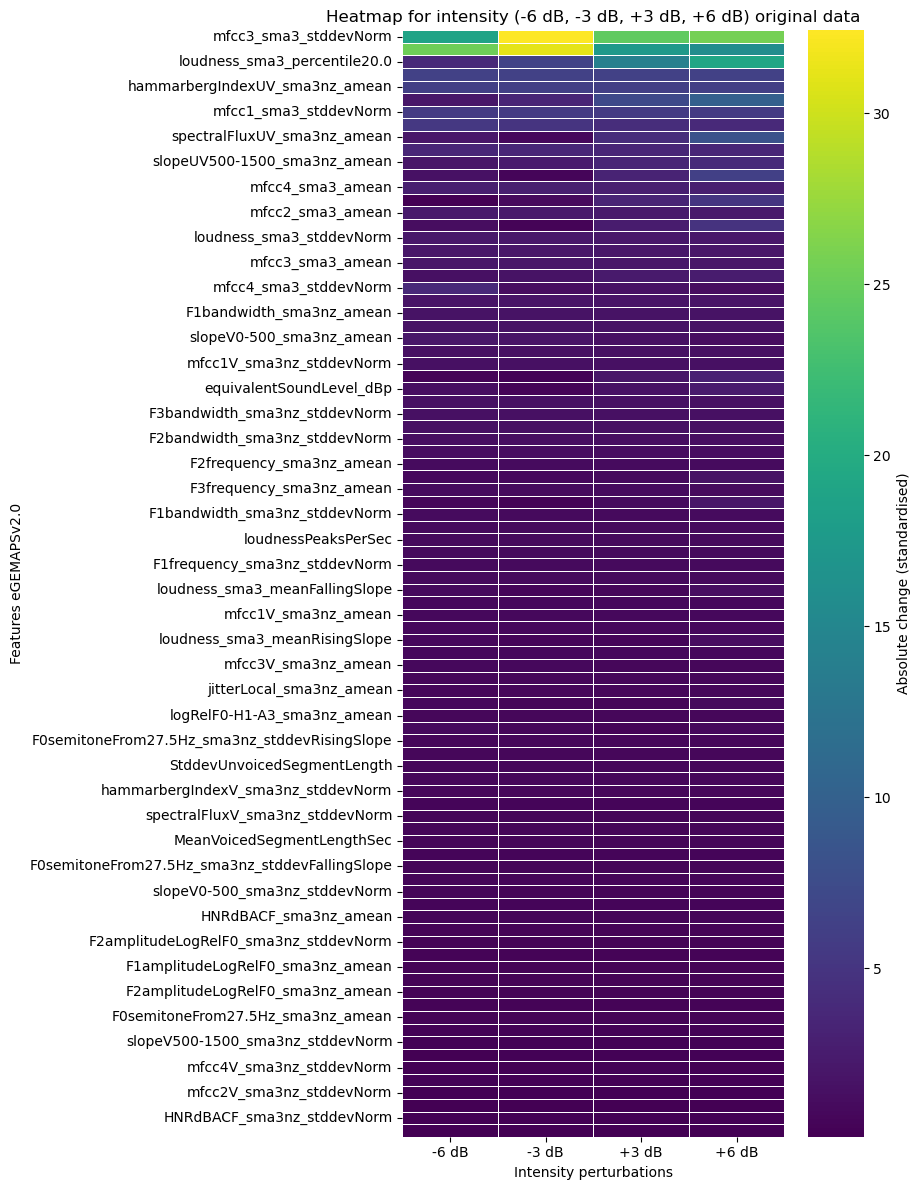

In [43]:
# path
BASE_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht"

files = {
    "original": os.path.join(BASE_PATH, "opensmile_wiener_features.csv"),
    "-6 dB": os.path.join(BASE_PATH, "original_opensmile_intensity_-6dB_features_pain.csv"),
    "-3 dB": os.path.join(BASE_PATH, "original_opensmile_intensity_-3dB_features_pain.csv"),
    "+3 dB": os.path.join(BASE_PATH, "original_opensmile_intensity_3dB_features_pain.csv"),
    "+6 dB": os.path.join(BASE_PATH, "original_opensmile_intensity_6dB_features_pain.csv"),
}

# data
dfs = {k: pd.read_csv(v) for k, v in files.items()}

for k in dfs:
    dfs[k] = dfs[k].sort_values(by=["participant_id", "filename"]).reset_index(drop=True)

reference_ids = dfs["original"][["participant_id", "filename"]]

for key in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    if not reference_ids.equals(dfs[key][["participant_id", "filename"]]):
        raise ValueError(f"Mismatch in {key}")

# features
exclude_cols = ["participant_id", "filename", "file_path", "name"]
numeric_cols = dfs["original"].select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

#standardisation with sklearn
# fit the scaler on the original data
scaler = StandardScaler()
scaler.fit(dfs["original"][feature_cols])
dfs_std = {}

for key, df in dfs.items():
    df_std = df.copy()
    df_std_features = scaler.transform(df[feature_cols]) # apply the same transformation also to the perturbated data (-3 dB, +3 dB, etc.)
    df_std[feature_cols] = df_std_features
    dfs_std[key] = df_std

# Absolute difference with standardised features
abs_diff_means = {}
original_features = dfs_std["original"][feature_cols]

for condition in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    perturbed_features = dfs_std[condition][feature_cols]

    abs_diff = np.abs(perturbed_features - original_features)
    abs_diff_means[condition] = abs_diff.mean(axis=0)

# heatmap
heatmap_df = pd.DataFrame(abs_diff_means)

heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
heatmap_df = heatmap_df.drop(columns=["mean_change"])

top_n = 88  # all features
heatmap_top = heatmap_df.head(top_n)

plt.figure(figsize=(9, 12))
sns.heatmap(
    heatmap_top,
    cmap="viridis",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Absolute change (standardised)"},
    annot=False
)

plt.title("Heatmap for intensity (-6 dB, -3 dB, +3 dB, +6 dB) original data")
plt.xlabel("Intensity perturbations")
plt.ylabel("Features eGEMAPSv2.0")
plt.tight_layout()
plt.show()